#  **Importing Libaries and data in dataframe**

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest 
FILE_PATH = 'kathmandu_monsoon_rides.csv'
df = pd.read_csv(FILE_PATH)
df['Is_Completed'] = np.where(df['Ride_Status'] =='Completed' ,1,0)
import warnings

# Suppress all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)
print(f"✅ Loaded {df.shape[0]:,} records from Kathmandu Monsoon Base.")


✅ Loaded 15,000 records from Kathmandu Monsoon Base.


# **TRANSACTION BEHAVIOR & PAYMENT CHANNEL FRICTION STUDY**

In [2]:
print("\n 🚀 STEP 2 : RUNNING PAYMENT CHANNEL FRICTION METRICES ...")
payment_analysis = df.groupby('Payment_Method').agg(
    Total_Bookings = ('Is_Completed' , 'count'),
    Completion_Rate = ('Is_Completed' , 'mean')
).reset_index()
#formula : np.sqrt(p*(1-p) / n )
payment_analysis['Standard_Error'] = np.sqrt(
    payment_analysis['Completion_Rate'] * (1 - payment_analysis['Completion_Rate']) / payment_analysis['Total_Bookings']
)

# 3. Apply the 95% Confidence boundary intervals (Z-score = 1.96)
payment_analysis['Lower_Bound'] = payment_analysis['Completion_Rate'] - (1.96 * payment_analysis['Standard_Error'])
payment_analysis['Upper_Bound'] = payment_analysis['Completion_Rate'] + (1.96 * payment_analysis['Standard_Error'])

# 4. Print the final calculated data matrix to your VS Code console terminal
print(payment_analysis.to_string(index=False))


 🚀 STEP 2 : RUNNING PAYMENT CHANNEL FRICTION METRICES ...
Payment_Method  Total_Bookings  Completion_Rate  Standard_Error  Lower_Bound  Upper_Bound
          Cash            3708         0.598975        0.008049     0.583200     0.614750
         Esewa            3841         0.511065        0.008066     0.495256     0.526874
       Fonepay            3761         0.503855        0.008153     0.487876     0.519835
        Khalti            3690         0.498645        0.008231     0.482512     0.514778


# **WHETHER IMPACT & PROOF OF SIGNIFICANCE (HYPOTHESIS TESTING)**

In [3]:
print("\n 🚀Running Whether impact significant testing----")
clear_weather_rides = df[df['Weather'] == 'Clear'] ['Is_Completed']
heavy_rain_rides = df[df['Weather'] == 'Heavy Monsoon Rain'] ['Is_Completed']
success_counts = np.array([clear_weather_rides.sum() , heavy_rain_rides.sum()])
total_observations = np.array([len(clear_weather_rides) , len(heavy_rain_rides)])

#calcualtion of Z_Stat & p-value
z_statistic , p_value = proportions_ztest(count = success_counts, nobs = total_observations, alternative='two-sided')
print(f"📊 Calculated Z-Statistic : {z_statistic:.4f}")
print(f" 🔬 Calculated P-Value : {p_value:.6f}")
print("\n 📋 DECISION LOGIC MATRIX:")

#Evaluation against standard significant threshold i.e level of significance(alpha = o.o5)
if p_value < 0.05:
    print("✨ RESULT :STATISTICALLY SIGNIFICANT")
    print(f"We reject the null Hypothesis. There is a less than {p_value*100:.4f}% chance this drop was a random fluke.")
else:
    print("❌ RESULT: NOT STATISTICALLY SIGNIFICANT.")
    print("We fail to reject the Null Hypothesis. The variance could easily be random noise.")


 🚀Running Whether impact significant testing----
📊 Calculated Z-Statistic : 28.5414
 🔬 Calculated P-Value : 0.000000

 📋 DECISION LOGIC MATRIX:
✨ RESULT :STATISTICALLY SIGNIFICANT
We reject the null Hypothesis. There is a less than 0.0000% chance this drop was a random fluke.


# **SITUATIONAL CRISIS BEHAVIOR (GRIDLOCK GRID ANALYSIS)**

In [4]:
print("\n 🚀 Step 4 : RUNNING GRIDLOCK SITUTIONAL MATRIX ANALYSIS....")
#============================================================================
gridlock_analysis = df.groupby(['Is_Peak_Hour' , 'Is_Bottleneck_Zone']).agg(
    Total_Bookings=('Is_Completed' , 'count'),
    Completion_Rate=('Is_Completed' , 'mean')).reset_index()
grid_matrix = gridlock_analysis.pivot(
    index='Is_Peak_Hour',
    columns='Is_Bottleneck_Zone',
    values='Completion_Rate'
)
# 3. Format the matrix values as clean percentages for easy reading
print("\n🗺️ KATHMANDU FULFILLMENT RISK MATRIX (COMPLETION %):")
print("[Rows: Is_Peak_Hour (0=Off-Peak, 1=Peak Rush) | Columns: Is_Bottleneck_Zone (0=Normal, 1=Bottleneck Zone)]")
print((grid_matrix * 100).round(2).to_string())


 🚀 Step 4 : RUNNING GRIDLOCK SITUTIONAL MATRIX ANALYSIS....

🗺️ KATHMANDU FULFILLMENT RISK MATRIX (COMPLETION %):
[Rows: Is_Peak_Hour (0=Off-Peak, 1=Peak Rush) | Columns: Is_Bottleneck_Zone (0=Normal, 1=Bottleneck Zone)]
Is_Bottleneck_Zone      0      1
Is_Peak_Hour                    
0                   64.89  53.05
1                   48.42  38.29


# **VISUALIZATION OF THE RESUTS OF EACH PHASES**


🎨 GENERATING VISUAL 1: PAYMENT CHANNEL FRICTION...


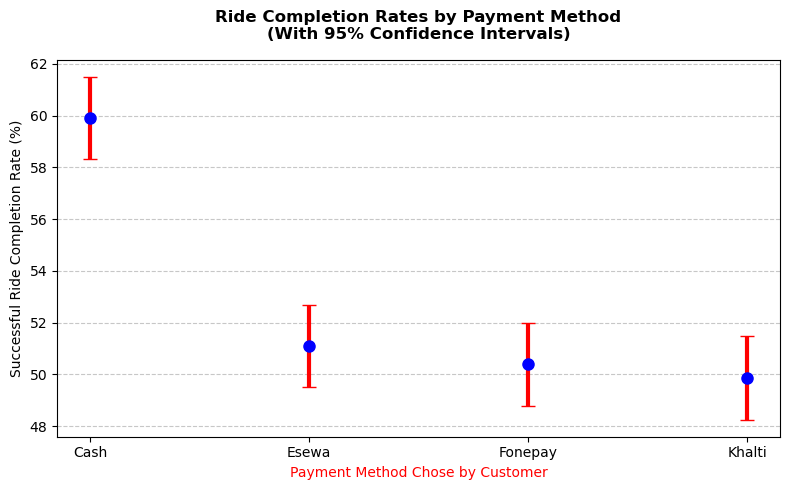

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
print("\n🎨 GENERATING VISUAL 1: PAYMENT CHANNEL FRICTION...")
plt.figure(figsize=(8,5))
# Calculate the length of the error bars from the center point
error_lower = payment_analysis['Completion_Rate'] - payment_analysis['Lower_Bound']
error_upper = payment_analysis['Upper_Bound'] - payment_analysis['Completion_Rate']
asymmetric_error = np.array(list(zip(error_lower, error_upper))).T

# Plot the points with their 95% Confidence Interval bars
plt.errorbar(
    x=payment_analysis['Payment_Method'],
    y=payment_analysis['Completion_Rate'] * 100,  # Convert to %
    yerr=asymmetric_error * 100,
    fmt='o', color='#0000FF', ecolor='#FF0000', elinewidth=3, capsize=5, markersize=8
)

plt.title('Ride Completion Rates by Payment Method\n(With 95% Confidence Intervals)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Payment Method Chose by Customer', fontsize=10 ,color='#FF0000')
plt.ylabel('Successful Ride Completion Rate (%)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()





🎨 GENERATING VISUAL 2: WEATHER COMPARISON...


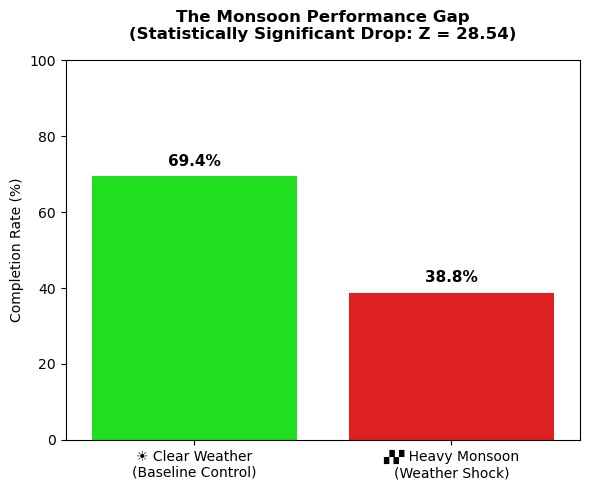

In [6]:
print("\n🎨 GENERATING VISUAL 2: WEATHER COMPARISON...")
plt.figure(figsize=(6, 5))

# Calculate completion rates directly for a quick comparative bar chart
weather_rates = [clear_weather_rides.mean() * 100, heavy_rain_rides.mean() * 100]
weather_labels = ['☀️ Clear Weather\n(Baseline Control)', '▞▞ Heavy Monsoon\n(Weather Shock)']

sns.barplot(x=weather_labels, y=weather_rates, palette=['#00FF00', '#FF0000'])

# Add value labels on top of the bars
for i, rate in enumerate(weather_rates):
    plt.text(i, rate + 2, f"{rate:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('The Monsoon Performance Gap\n(Statistically Significant Drop: Z = 28.54)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Completion Rate (%)', fontsize=10)
plt.ylim(0, 100)  # Keeps scale honest
plt.tight_layout()
plt.show()


🎨 GENERATING VISUAL 3: SITUATIONAL CRISIS HEATMAP...


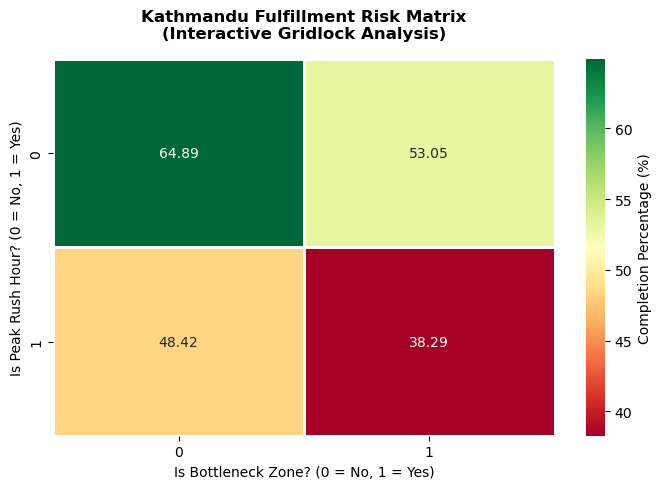

In [7]:
print("\n🎨 GENERATING VISUAL 3: SITUATIONAL CRISIS HEATMAP...")
plt.figure(figsize=(7, 5))

# Convert decimal rates to clean percentage values for the visual matrix
heatmap_data = grid_matrix * 100

# Plot using Seaborn's heatmap engine
sns.heatmap(
    heatmap_data, 
    annot=True,             # Write the percentage numbers inside the boxes
    fmt=".2f",              # Decimal formatting
    cmap="RdYlGn",          # Red (Low Completion) to Green (High Completion) scale
    cbar_kws={'label': 'Completion Percentage (%)'},
    linewidths=1, linecolor='white'
)

plt.title('Kathmandu Fulfillment Risk Matrix\n(Interactive Gridlock Analysis)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Is Bottleneck Zone? (0 = No, 1 = Yes)', fontsize=10)
plt.ylabel('Is Peak Rush Hour? (0 = No, 1 = Yes)', fontsize=10)
plt.tight_layout()
plt.show()

# **PREDICT CUSTOMR CANCELLATIONS (MACHINE LEARNING PREDICTIVE LAYER)**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("\n🚀 TRAINING BEHAVIORAL PREDICTION ENGINE...")
#Feature Engineering : Convert categorical features to dummy variable
features = pd.get_dummies(df[['Payment_Method', 'Weather', 'Is_Peak_Hour', 'Is_Bottleneck_Zone']], drop_first=True)
target = df['Is_Completed']
# 2. Split into Train & Test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# 3. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate Predictive Accuracy
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))



🚀 TRAINING BEHAVIORAL PREDICTION ENGINE...
              precision    recall  f1-score   support

           0       0.63      0.62      0.63      1444
           1       0.66      0.66      0.66      1556

    accuracy                           0.65      3000
   macro avg       0.64      0.64      0.64      3000
weighted avg       0.65      0.65      0.65      3000

